# 03 — Integration, Universal Dataset & Schema
.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json, os

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

df1_copy  = pd.read_csv('data/processed/clinical_clean.csv')
df2_clean = pd.read_csv('data/processed/biospecimen_clean.csv')
print('Clinical :', df1_copy.shape)
print('Biospecimen :', df2_clean.shape)

Clinical : (608, 11)
Biospecimen : (608, 9)


In [2]:
overlap = set(df1_copy.columns) & set(df2_clean.columns) - {'case_id'}
print('Overlapping columns (will get suffix):', overlap)

Overlapping columns (will get suffix): set()


## 2. Merge — Universal Dataset

In [3]:
universal_df = pd.merge(
    df2_clean,
    df1_copy,
    on='case_id',
    how='left',
    suffixes=('_biospc', '_clin')
)
print('Universal shape :', universal_df.shape)
print('Unique patients :', universal_df['case_id'].nunique())

Universal shape : (608, 19)
Unique patients : 608


## 3. Merge Validation

In [4]:
matched   = universal_df['age_at_index'].notna().sum()
total     = len(universal_df)
unmatched = universal_df[universal_df['age_at_index'].isna()]['case_id'].nunique()

print(f'Match rate : {matched}/{total} ({matched/total*100:.1f}%)')
print(f'Unmatched case_ids: {unmatched}')

if unmatched > 0:
    print('\nSample unmatched IDs:')
    print(universal_df[universal_df['age_at_index'].isna()]['case_id'].unique()[:5])

Match rate : 608/608 (100.0%)
Unmatched case_ids: 0


## 4. Cross-Dataset Visualizations

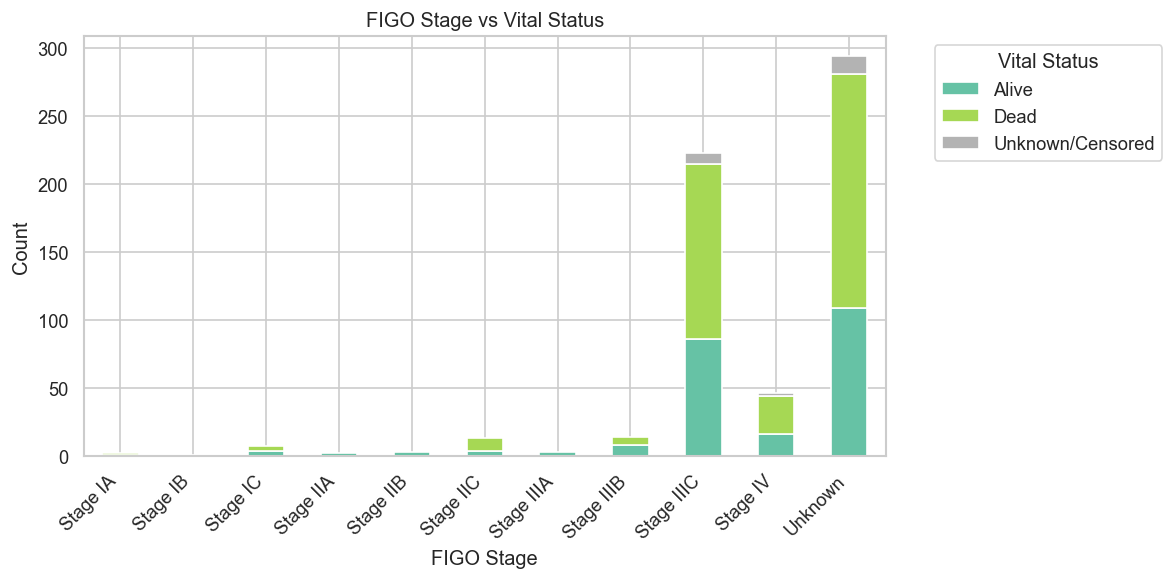

In [5]:
ct = pd.crosstab(universal_df['figo_stage'], universal_df['vital_status'])
ct.plot(kind='bar', stacked=True, figsize=(10, 5), colormap='Set2', edgecolor='white')
plt.title('FIGO Stage vs Vital Status')
plt.xlabel('FIGO Stage')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Vital Status', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.savefig('data/processed/plots/plot_stage_vs_vital.png', dpi=150)
plt.show()

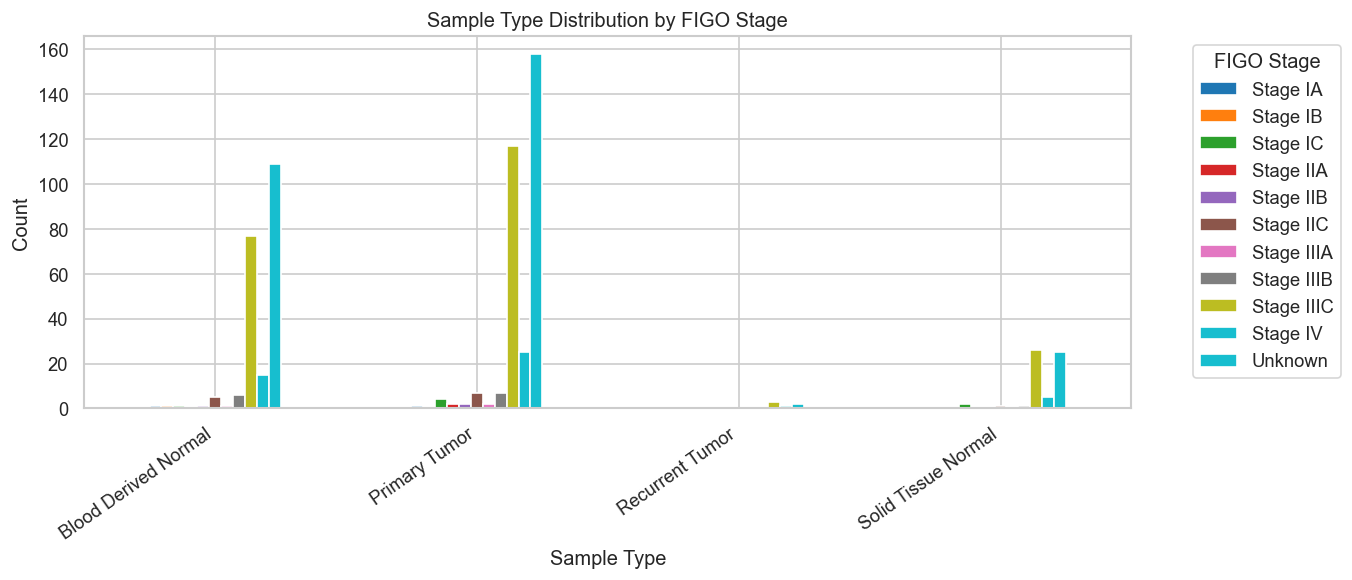

In [6]:
ct2 = pd.crosstab(universal_df['sample_type'], universal_df['figo_stage'])
ct2.plot(kind='bar', figsize=(10, 5), colormap='tab10', edgecolor='white')
plt.title('Sample Type Distribution by FIGO Stage')
plt.xlabel('Sample Type')
plt.ylabel('Count')
plt.xticks(rotation=35, ha='right')
plt.legend(title='FIGO Stage', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.savefig('data/processed/plots/plot_sample_by_stage.png', dpi=150)
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_15904\2606797197.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=universal_df, x='vital_status', y='age_at_index', palette='Set3')


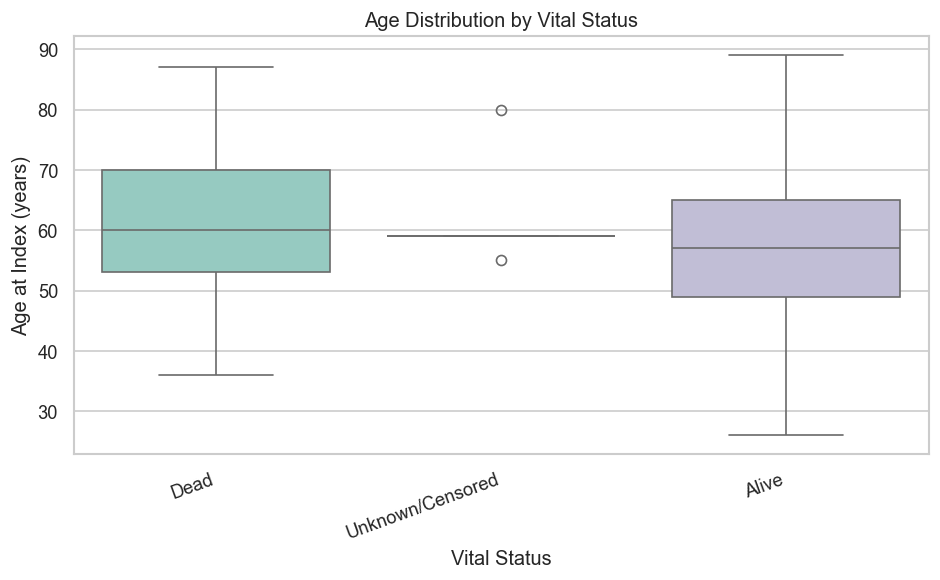

In [7]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=universal_df, x='vital_status', y='age_at_index', palette='Set3')
plt.title('Age Distribution by Vital Status')
plt.xlabel('Vital Status')
plt.ylabel('Age at Index (years)')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('data/processed/plots/plot_age_by_vital.png', dpi=150)
plt.show()

## 5. Final Audit

In [8]:
print('=' * 50)
print('UNIVERSAL DATASET — FINAL AUDIT')
print('=' * 50)
print(f'Rows            : {universal_df.shape[0]}')
print(f'Columns         : {universal_df.shape[1]}')
print(f'Unique patients : {universal_df["case_id"].nunique()}')
print('\nMissingness (%) — top 15:')
print(universal_df.isna().mean().mul(100).sort_values(ascending=False).head(15).round(1).to_string())
print('\nColumn dtypes:')
print(universal_df.dtypes)

UNIVERSAL DATASET — FINAL AUDIT
Rows            : 608
Columns         : 19
Unique patients : 608

Missingness (%) — top 15:
analyte_type        47.0
days_to_death       42.8
case_id              0.0
tumor_descriptor     0.0
submitter_id         0.0
tissue_type          0.0
sample_id            0.0
weight               0.0
is_ffpe              0.0
primary_site         0.0
sample_type          0.0
disease_type         0.0
sex_at_birth         0.0
days_to_birth        0.0
age_at_index         0.0

Column dtypes:
case_id              object
submitter_id         object
tumor_descriptor     object
sample_id            object
sample_type          object
tissue_type          object
weight              float64
is_ffpe                bool
analyte_type         object
primary_site         object
disease_type         object
sex_at_birth         object
age_at_index        float64
days_to_birth       float64
race                 object
vital_status         object
days_to_death       float64
figo_stag

## 6. Export Schema & Metadata

In [9]:
for f in ['../schema.json', '../metadata.json']:
    status = 'EXISTS' if os.path.exists(f) else 'MISSING'
    print(f'{f}: {status}')

../schema.json: EXISTS
../metadata.json: EXISTS


In [10]:
universal_df.to_csv('C:/Users/user/Desktop/Ovarian Task/Data/Processed/universal_dataset.csv', index=False)
